<a href="https://colab.research.google.com/github/ewst22ParkSY/ESAA11_PSY/blob/ESAA11_OB/ESAA_OB_WEEK4_1_transcript.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## NLP ? 텍스트 분석?
- NLP(National LAnguage Processing): 머신이 인간의 언어를 이해하고 해석하는 데 더 중점을 두고 기술이 발전

- 텍스트 분석(= 텍스트 마이닝 Text Mining): 비정형 텍스트에서 의미 있는 정보를 추출하는 것에 좀 더 중점을 두고 기술 발전

+ NLP: 텍스트 분석을 향상하게 하는 기반 기술.

텍스트분석
- 머신러닝, 언어 이해, 통계 등을 활용해 모델 수립, 정보 추출, 비즈니스 인텔리전스(Business INtelligence), 예측 분석 등의 분석 작업 수행
- 하단의 기술 영역에 집중
> 텍스트 분류, 감성 분석, 텍스트 요약, 텍스트 군집화와 유사도

## 1. 텍스트 분석 이해
- 비정형 데이터인 텍스트를 분석하는 것
- 비정형 텍스트 데이터를 어떻게 피처 형태로 추출하고 추출된 피처에 의미 있는 값을 부여하는가 하는 것이 매우 중요한 요소

피처 벡터화(Feature Vectorization), 피처 추출(Feature Extraction)
- 텍스트를 word(또는 word의 일부분) 기반의 다수의 피처로 추출, 피처에 단어 빈도수와 같은 숫자 값 부여시 텍스트는 단어의 조합인 벡터값으로 표현되어 변환
- BOW(Bag of Words)와 Word2Vec 방법이 있음.

### 텍스트 분석 수행 프로세스
1. 텍스트 사전 준비작업(텍스트 전처리)
2. 피처 벡터화/추출
3. ML 모델 수립 및 학습/예측/평가

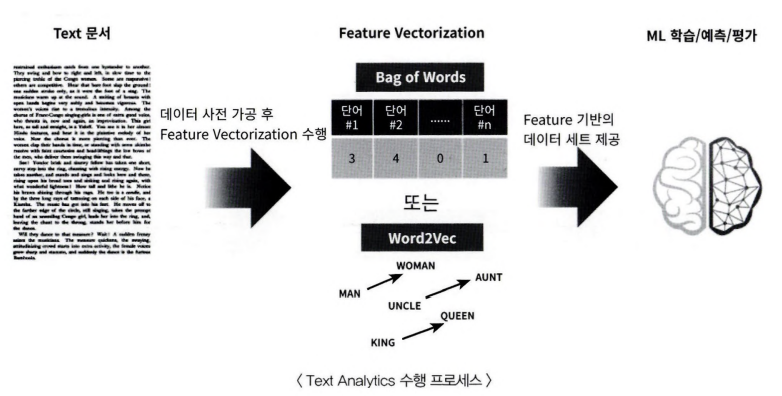


### 파이썬 기반의 NLP, 텍스트 분석 패키지
- NLTK, gensim, spaCy

NLTK
- 방대한 데이터 세트와 서브 모듈, 다양한 데이터 세트를 지원해 오래전부터 대표적인 파이썬 NLP 패키지
- 수행 성능과 정확도, 신기술, 엔터프라이즈한 기능 지원 등의 측면에서 부족함

Genism, SpaCy
- NLTK의 이런 부분을 보완하며 실제 업무에서 자주 활용되는 패키지

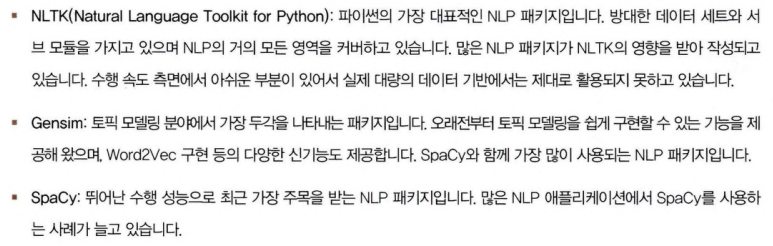

## 02 텍스트 사전 준비 작업(텍스트 전처리) - 텍스트 정규화
- 텍스트를 머신러닝 알고리즘이나 NLP 애플리케이션에 입력 데이터로 사용하기 위해 클렌징, 정제, 토큰화, 어근화 등의 다양한 텍스트 데이터의 사전 작업을 수행하는 것

### 순서
- 클렌징(Cleansing)
- 토큰화(Tokenization)
- 필터링/스톱 워드 제거/철자 수정
- Stemming
- Lemmatization

### 클렌징
- 텍스트에서 분석에 오히려 방해가 되는 불필요한 문자, 기호 등을 사전에 제거하는 작업
> HTML, XML 태그나 특정 기호 등

### 텍스트 토큰화
- 문장 토큰화: 문서에서 문장 분리
- 단어 토큰화: 문장에서 단어 분리


#### 문장 토큰화
- 문장의 마침표(.), 개행문자(\n)  등 문장의 마지막을 뜻하는 기호에 따라 분리하는 것이 일반적
- 정규 표현식에 따른 문장 토큰화 가능

In [12]:
from nltk import sent_tokenize
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

text_sample =  'The Matrix is everywhere its all around us, here even in this room. \
You can see it out your window or on your television. \
You feel it when you go to work, or go to church or pay your taxes.'

sentences = sent_tokenize(text=text_sample)
print(type(sentences), len(sentences))
print(sentences)

<class 'list'> 3
['The Matrix is everywhere its all around us, here even in this room.', 'You can see it out your window or on your television.', 'You feel it when you go to work, or go to church or pay your taxes.']


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


sent_tokenize()가 반환하는 것은 각각의 문장으로 구성된 list 객체.

#### 단어 토큰화
- 문장을 단어로 토큰화하는 것.
> 공백, 콤마(,), 마침표(.), 개행문자 등으로 단어를 분리. <br>
> 정규 표현식을 이용해 다양한 유형으로 토큰화 수행가능

문장을 분리하는 구분자(마침표 or 개행문자)를 이용해 단어를 토큰화할 수 있으므로 Bag of Word와 같이 단어의 순서가 중요하지 않은 경우 문장 토큰화를 사용하지 않고 단어 토큰화만 사용해도 충분.

In [13]:
from nltk import word_tokenize

sentence = "The Matrix is everywhere its all around us, here even in this room."
words = word_tokenize(sentence)
print(type(words), len(words))
print(words)

<class 'list'> 15
['The', 'Matrix', 'is', 'everywhere', 'its', 'all', 'around', 'us', ',', 'here', 'even', 'in', 'this', 'room', '.']


In [15]:
# 문서에 대해 모든 단어 토큰화

from nltk import word_tokenize, sent_tokenize

# 여러 개의 문장으로 된 입력 데이터를 문장별로 단어 토큰화하게 만드는 함수 생성
def tokenize_text(text):

    # 문장별로 분리 토큰
    sentences = sent_tokenize(text)
    # 분리된 문장별 단어 토큰화
    word_tokens = [word_tokenize(sentence) for sentence in sentences]
    return word_tokens

# 여러 문장에 대해 문장별 단어 토큰화 수행
word_tokens = tokenize_text(text_sample)
print(type(word_tokens), len(word_tokens))
print(word_tokens)

<class 'list'> 3
[['The', 'Matrix', 'is', 'everywhere', 'its', 'all', 'around', 'us', ',', 'here', 'even', 'in', 'this', 'room', '.'], ['You', 'can', 'see', 'it', 'out', 'your', 'window', 'or', 'on', 'your', 'television', '.'], ['You', 'feel', 'it', 'when', 'you', 'go', 'to', 'work', ',', 'or', 'go', 'to', 'church', 'or', 'pay', 'your', 'taxes', '.']]


- 문장을 단어별로 하나씩 토큰화 할 경우 문맥적인 의미는 무시될 수밖에 없음.
> 이 문제를 해결하기 위해 도입된 것: n-gram

n-gram
- 연속된 n개의 단어를 하나의 토큰화 단위로 분리해 내는 것


### 스톱 워드 제거
스톱 워드(Stop word): 분석에 큰 의미가 없는 단어 지칭 (is, the, a, will 등의 필수 문법 요소이나 문맥적으로 큰 의미가 없는 단어)


In [16]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [17]:
print('영어 stop words 개수:', len(nltk.corpus.stopwords.words('english')))
print(nltk.corpus.stopwords.words('english')[ :20])

영어 stop words 개수: 198
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been']


In [18]:
import nltk

stopwords = nltk.corpus.stopwords.words('english')
all_tokens = []
# 위 예제에서 3개의 문장별로 얻은 word_tokens list에 대해 스톱 워드를 제거하는 반복문

for sentence in word_tokens:
    filtered_words = []
    # 개별 문장별로 토큰화된 문장 list에 대해 스톱 워드를 제거하는 반복문
    for word in sentence :
        # 소문자로 모두 변환
        word = word.lower()
        # 토큰화된 개별 단어가 스톱 워드의 단어에 포함되지 않으면 word_tokens에 추가
        if word not in stopwords :
            filtered_words.append(word)
    all_tokens.append(filtered_words)

print(all_tokens)

[['matrix', 'everywhere', 'around', 'us', ',', 'even', 'room', '.'], ['see', 'window', 'television', '.'], ['feel', 'go', 'work', ',', 'go', 'church', 'pay', 'taxes', '.']]


### stemming과 Lemmatization
- 문법적 또는 의미적으로 변화하는 단어의 원형을 찾는 것

Lemmatization > Stemming
- 더 정교하며, 의미론적인 기반에서 단어의 원형을 찾음
- 변환에 더 오랜 시간을 필요로 함.

Stemming: 원형 단어로 변환 시 일반적인 방법을 적용하거나 더 단순화된 방법을 적용

Stemming: 일부 철자가 훼손된 어근 단어를 추출하는 경향이 있음.

Lemmatization: 품사와 같은 문법적인 요소와 더 의미적인 부분을 감안해 정확한 철자로 된 어근 단어를 찾아줌.


In [19]:
from nltk.stem import LancasterStemmer
stemmer = LancasterStemmer()

print(stemmer.stem('working'), stemmer.stem('works'), stemmer.stem('worked'))
print(stemmer.stem('amusing'), stemmer.stem('amuses'), stemmer.stem('amused'))
print(stemmer.stem('happier'), stemmer.stem('happiest'))
print(stemmer.stem('fancier'), stemmer.stem('fanciest'))

work work work
amus amus amus
happy happiest
fant fanciest


In [20]:
from nltk.stem import WordNetLemmatizer
import nltk
nltk.download('wordnet')

lemma = WordNetLemmatizer()
print(lemma.lemmatize('amusing','v'), lemma.lemmatize('amuses', 'v'), lemma.lemmatize('amused', 'v'))
print(lemma.lemmatize('happier', 'a'), lemma.lemmatize('happiest', 'a'))
print(lemma.lemmatize('fancier', 'a'), lemma.lemmatize('fanciest', 'a'))

amuse amuse amuse
happy happy
fancy fancy


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


### Bag of Words - BOW

- 문서가 가지는 모든 단어(Words)를 문맥이나 순서를 무시하고 일괄적으로 단어에 대해 빈도 값을 부여해 피처 값을 추출하는 모델.

장점
- 쉽고 빠른 구축.

단점
- 문맥 의미(Semantic Context) 반영 부족
- 희소 행렬 문제(희소성, 희소 행렬)

### BOW 피처 벡터화
- 텍스트를 특정 의미가 가지는 숫자형 값(벡터 값)으로 변환하는 것
- 각 단어의 발생 빈도와 같은 값을 피처에 값으로 부여해 각 문서를 이 단어 피처의 발생 빈도 값으로 구성된 벡터로 만드는 기법
- 넓은 범위의 피처 추출에 포함.

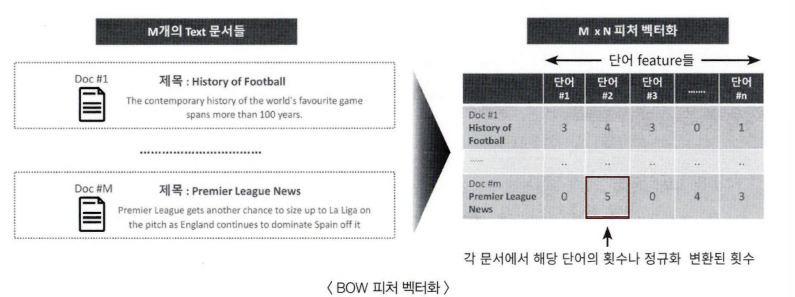

결과적으로: MxN개의 단어 피처로 이뤄진 행렬을 구성하게 됨.

BOW의 피처 벡터화 방식
- 카운트 기반의 벡터화
- TF-IDF(Term Frequency - Inverse Document Frequency) 기반의 벡터화

모든 문서에서 반복적으로 자주 발생하는 단어에 대해서 페널티를 부여하는 방식으로 단어에 대한 가중치의 균형을 맞춤.

문서마다 텍스트가 길고 문서의 개수가 많은 경우 카운트 방식보다는 TF-IDF 방식을 사용하는 것이 더 좋은 예측 성능을 보장

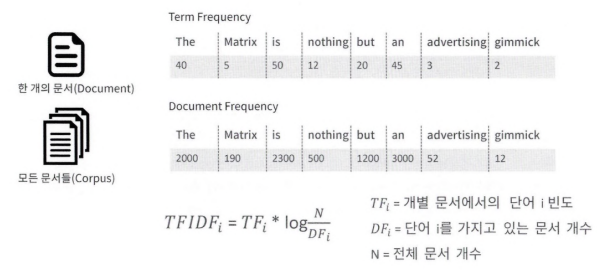

### 사이킷런의 Count 및 TF-IDF 벡터화 구현: CountVectorizer, TfidfVectorizer

-CountVectorizer
- 피처 벡터화만 수행하는 것 X
- 소문자 일괄 변환, 토큰화, 스톱 워드 필터링 등의 텍스트 전처리 함께 수행
- fit()과 transform()을 통해 피처 벡터화된 객체 반환

CountVectorizer 입력 파라미터
- max_df
- min_df
- max_features
- stop_words
- n_gram_range
- analyzer
- token_pattern
- tokenizer

사이킷런의 CountV ectorizer 클래스를 이용해 카운트 기반의 피처 여러 개의 문서로 구성된 텍스트의 피처 벡터화 방법
1. 모든 문자를 소문자로 변경하는 등의 전처리 작업 수행
2. 디폴트로 단어 기준으로 n_gram_range를 반영해 각 단어 토큰화
3. 텍스트 정규화 수행
> stop_words='english'와 같이 stop_words 파라미터가 주어진 경우 스톱 워드 필터링만 가능.

시각화<br>
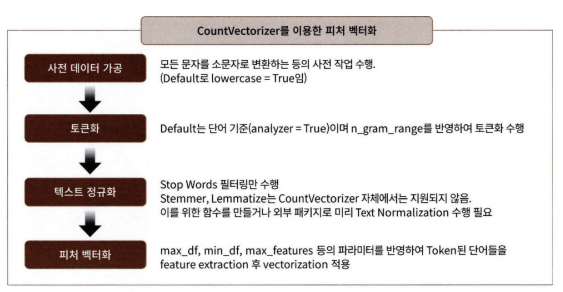

### BOW 벡터화를 위한 희소 행렬
- 텍스트를 피처 단위로 벡터화해 변환하고 CSR 형태의 희소 행렬 반환

희소 행렬?
- 모든 문서의 단어를 추출해 피처로 벡터화하게 되면 많은 피처 칼럼이 만들어짐
- 대규모의 행렬이 생성되더라도 레코드의 각 문서가 가지는 단어의 수는 제한적(행렬의 값이 대부분 0)
> 대규모 행렬의 대부분의 값을 0이 차지하는 행렬을 희소 행렬이라고 함.
- BOW 형태를 가진 언어 모델의 피처 벡터화는 대부분 희소 행렬

희소 행렬을 물리적으로 적은 메모리 공간에 차지할 수 있도록 변환하는 방법
- COO, CSR 형식

### 희소 행렬 - COO 형식
> COO(Coordinate: 좌표) 형식: 0이 아닌 데이터만 별도의 데이터 배열(Array)에 저장하고, 그 데이터가 가리키는 행과 열의 위치를 별도로 배열로 저장하는 방식

- 주로 사이파이(Scipy) 이용.

In [23]:
import numpy as np

dense = np.array([ [3, 0, 1], [0,  2,  0] ])

In [24]:
from scipy import sparse

# 0이 아닌 데이터 추출
data = np.array([3, 1, 2])

# 행 위치와 열 위치를 각각 배열로 생성
row_pos = np.array([0, 0, 1])
col_pos = np.array([0, 2, 1])

# sparse 패키지의 coo_matrix를이용해 COO 형식으로 희소 행렬 생성
sparse_coo = sparse.coo_matrix((data, (row_pos, col_pos)))

In [25]:
#toarray() 메서드를 이용해 다시 밀집 형태의 행렬로 출력

sparse_coo.toarray()

array([[3, 0, 1],
       [0, 2, 0]])

### 희소 행렬 - CSR 형식
- Compressed Sparse Row
- COO 형식이 행과 열의 위치를 나타내기 위해서 반복적인 위치 데이터를 사용해야 하는 문제점을 해결한 방식

예시<br>
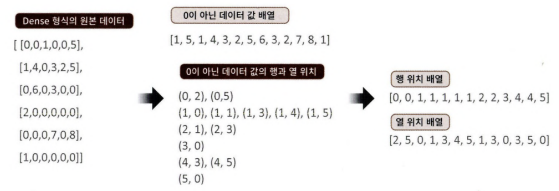


- 행 위치 배열 내에 있는 고유한 값의 시작 위치만 다시 별도의 위치 배열로 가지는 변환 방식
- 고유 값의 시작 위치를 알고 있을 경우 얼마든지 행 위치 배열을 다시 만들 수 있기에 COO 방식보다 메모리가 적게 들고 빠른 연산이 가능함.

In [27]:
from scipy import sparse

dense2 = np.array([[0, 0, 1, 0, 0, 5],
                                     [1, 4, 0, 3, 2, 5],
                                     [0, 6, 0, 3 , 0, 0],
                                     [2, 0, 0, 0, 0, 0],
                                     [0, 0, 0, 7, 0, 8],
                                     [1, 0, 0, 0, 0, 0]])

#0이 아닌 데이터 추출
data2 = np.array([1, 5, 1, 4, 3, 2, 5, 6, 3, 2, 7, 8, 1 ])

#행 위치와 열 위치를 각각 array로 생성
row_pos = np.array([0, 0, 1, 1, 1, 1, 1, 2, 2, 3, 4, 4, 5])
col_pos = np.array([2, 5, 0, 1, 3, 4, 5, 1, 3, 0, 3, 5, 0])

#COO 형식으로 변환
sparse_coo = sparse.coo_matrix((data2, (row_pos, col_pos)))

#행 위치 배열의 고유한 값의 시작 위치 인덱스를 배열로 생성
row_pos_ind = np.array([0, 2, 7, 9, 10, 12, 13])

#CSR 형식으로 변환
sparse_csr = sparse.csr_matrix((data2, col_pos, row_pos_ind))
print('COO 변환된 데이터가 제대로 되었는지 다시 Dense로 출력 확인')
print(sparse_coo.toarray())
print('CSR 변환된 데이터가 제대로 되었는지 다시 Dense로 출력 확인')
print(sparse_csr.toarray())


COO 변환된 데이터가 제대로 되었는지 다시 Dense로 출력 확인
[[0 0 1 0 0 5]
 [1 4 0 3 2 5]
 [0 6 0 3 0 0]
 [2 0 0 0 0 0]
 [0 0 0 7 0 8]
 [1 0 0 0 0 0]]
CSR 변환된 데이터가 제대로 되었는지 다시 Dense로 출력 확인
[[0 0 1 0 0 5]
 [1 4 0 3 2 5]
 [0 6 0 3 0 0]
 [2 0 0 0 0 0]
 [0 0 0 7 0 8]
 [1 0 0 0 0 0]]


In [28]:
dense3 = np.array([[0, 0, 1, 0, 0, 5],
                    [1, 4, 0, 3, 2, 5],
                    [0, 6, 0, 3, 0, 0],
                    [2, 0, 0, 0, 0, 0],
                    [0, 0, 0, 7, 0, 8],
                    [1, 0, 0, 0, 0, 0]])

coo = sparse.coo_matrix(dense3)
csr = sparse.csr_matrix(dense3)